<a href="https://colab.research.google.com/github/Harvindar23/CovidDataAnalysis/blob/main/Covid_19_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_original=pd.read_csv('Provisional_COVID-19_Deaths_by_Sex_and_Age.csv')

# creating a copy of original dataset
df=df_original.copy()
print("Shape of the dataSet" ,df.shape)
print("\n\n ----------------------------------- \n\n")
print(df.info())

Shape of the dataSet (94029, 16)


 ----------------------------------- 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94029 entries, 0 to 94028
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Data As Of                                94029 non-null  object 
 1   Start Date                                94029 non-null  object 
 2   End Date                                  94029 non-null  object 
 3   Group                                     94028 non-null  object 
 4   Year                                      91274 non-null  float64
 5   Month                                     80258 non-null  float64
 6   State                                     94028 non-null  object 
 7   Sex                                       94028 non-null  object 
 8   Age Group                                 94028 non-null  object 
 9   COVID-19 Deaths               

In [ ]:

print("To know number of missing values in each  column\n", df.isnull().sum())


To know number of missing values in each  column
 Data As Of                                      0
Start Date                                      0
End Date                                        0
Group                                           1
Year                                         2755
Month                                       13771
State                                           1
Sex                                             1
Age Group                                       1
COVID-19 Deaths                             26545
Total Deaths                                12283
Pneumonia Deaths                            29741
Pneumonia and COVID-19 Deaths               24891
Influenza Deaths                            18942
Pneumonia, Influenza, or COVID-19 Deaths    29239
Footnote                                    28402
dtype: int64


In [ ]:
#to make column names as python naming convention so , it become  more convinent to work
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.info()) # to see the names of columns
print('\n\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94029 entries, 0 to 94028
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   data_as_of                                94029 non-null  object 
 1   start_date                                94029 non-null  object 
 2   end_date                                  94029 non-null  object 
 3   group                                     94028 non-null  object 
 4   year                                      91274 non-null  float64
 5   month                                     80258 non-null  float64
 6   state                                     94028 non-null  object 
 7   sex                                       94028 non-null  object 
 8   age_group                                 94028 non-null  object 
 9   covid-19_deaths                           67484 non-null  float64
 10  total_deaths                      

In [ ]:
#starting with data cleaning
print(df['group'].value_counts())
print('\n\n')
# df.shape

group
By Month    80258
By Year     11016
By Total     2754
Name: count, dtype: int64





In [ ]:

df_numeric=df.select_dtypes(include=np.number)
l=df_numeric.columns[2:]
print(l)


Index(['covid-19_deaths', 'total_deaths', 'pneumonia_deaths',
       'pneumonia_and_covid-19_deaths', 'influenza_deaths',
       'pneumonia,_influenza,_or_covid-19_deaths'],
      dtype='object')


In [ ]:
print("To prove the ambiguity/repetation of the same data: -> ")
df.groupby('group')[l].sum()

To prove the ambiguity/repetation of the same data: -> 


,covid-19_deaths,total_deaths,pneumonia_deaths,pneumonia_and_covid-19_deaths,influenza_deaths,"pneumonia,_influenza,_or_covid-19_deaths"
group,,,,,,
By Month,8395873.0,91326693.0,8506089.0,4178480.0,139543.0,12875206.0
By Total,10312761.0,111992961.0,10463467.0,5163215.0,201995.0,15797027.0
By Year,10305138.0,111991802.0,10454741.0,5156334.0,192021.0,15788311.0


In [ ]:
#removing the duplicacy/ repeated data
df=df[df['group'] == 'By Month']
print(df.isnull().sum() )
print('\n\n')
#by performing the above step the missing values in the 'year' and 'month' is removed

data_as_of                                      0
start_date                                      0
end_date                                        0
group                                           0
year                                            0
month                                           0
state                                           0
sex                                             0
age_group                                       0
covid-19_deaths                             23326
total_deaths                                12060
pneumonia_deaths                            26595
pneumonia_and_covid-19_deaths               21731
influenza_deaths                            12924
pneumonia,_influenza,_or_covid-19_deaths    26499
footnote                                    23544
dtype: int64





In [ ]:
#handling the missing values in rest of columns
rows=df[~df['footnote'].isnull()].index
df.loc[rows, l]=df.loc[rows,l].fillna(5)
print(df.isnull().sum()) #none of the column has missing values other than footnote

data_as_of                                      0
start_date                                      0
end_date                                        0
group                                           0
year                                            0
month                                           0
state                                           0
sex                                             0
age_group                                       0
covid-19_deaths                                 0
total_deaths                                    0
pneumonia_deaths                                0
pneumonia_and_covid-19_deaths                   0
influenza_deaths                                0
pneumonia,_influenza,_or_covid-19_deaths        0
footnote                                    23544
dtype: int64


In [ ]:

df

,data_as_of,start_date,end_date,group,year,month,state,sex,age_group,covid-19_deaths,total_deaths,pneumonia_deaths,pneumonia_and_covid-19_deaths,influenza_deaths,"pneumonia,_influenza,_or_covid-19_deaths",footnote
13770,09/27/2023,01/01/2020,01/31/2020,By Month,2020.0,1.0,United States,All Sexes,All Ages,6.0,264677.0,17909.0,3.0,2125.0,20037.0,NaN
13771,09/27/2023,01/01/2020,01/31/2020,By Month,2020.0,1.0,United States,All Sexes,Under 1 year,0.0,1784.0,41.0,0.0,8.0,49.0,NaN
13772,09/27/2023,01/01/2020,01/31/2020,By Month,2020.0,1.0,United States,All Sexes,0-17 years,0.0,2966.0,90.0,0.0,63.0,153.0,NaN
13773,09/27/2023,01/01/2020,01/31/2020,By Month,2020.0,1.0,United States,All Sexes,1-4 years,0.0,315.0,22.0,0.0,18.0,40.0,NaN
13774,09/27/2023,01/01/2020,01/31/2020,By Month,2020.0,1.0,United States,All Sexes,5-14 years,0.0,471.0,21.0,0.0,29.0,50.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94023,09/27/2023,08/01/2023,08/31/2023,By Month,2023.0,8.0,New York City,Male,55-64 years,5.0,421.0,18.0,0.0,0.0,20.0,One or more data cells have counts between 1-9...
94024,09/27/2023,08/01/2023,08/31/2023,By Month,2023.0,8.0,New York City,Male,65-74 years,5.0,472.0,43.0,5.0,0.0,46.0,One or more data cells have counts between 1-9...
94025,09/27/2023,08/01/2023,08/31/2023,By Month,2023.0,8.0,New York City,Male,75-84 years,11.0,519.0,39.0,5.0,0.0,47.0,One or more data cells have counts between 1-9...
94026,09/27/2023,08/01/2023,08/31/2023,By Month,2023.0,8.0,New York City,Male,85 years and over,14.0,448.0,47.0,5.0,0.0,55.0,One or more data cells have counts between 1-9...


In [ ]:
#changing the dattype of each column for saving memory usage

category=df.select_dtypes(exclude=np.number).columns
print(category)
for i in category[0:3]:
    df[i] = pd.to_datetime(df[i], format="%m/%d/%Y", errors='coerce')
df['month']=df['start_date'].dt.month_name()
category=list(category[3:])
category.extend(['year','month'])
df[category]=df[category].astype('category')
# print(category)
df

Index(['data_as_of', 'start_date', 'end_date', 'group', 'state', 'sex',
       'age_group', 'footnote'],
      dtype='object')


,data_as_of,start_date,end_date,group,year,month,state,sex,age_group,covid-19_deaths,total_deaths,pneumonia_deaths,pneumonia_and_covid-19_deaths,influenza_deaths,"pneumonia,_influenza,_or_covid-19_deaths",footnote
13770,2023-09-27,2020-01-01,2020-01-31,By Month,2020.0,January,United States,All Sexes,All Ages,6.0,264677.0,17909.0,3.0,2125.0,20037.0,NaN
13771,2023-09-27,2020-01-01,2020-01-31,By Month,2020.0,January,United States,All Sexes,Under 1 year,0.0,1784.0,41.0,0.0,8.0,49.0,NaN
13772,2023-09-27,2020-01-01,2020-01-31,By Month,2020.0,January,United States,All Sexes,0-17 years,0.0,2966.0,90.0,0.0,63.0,153.0,NaN
13773,2023-09-27,2020-01-01,2020-01-31,By Month,2020.0,January,United States,All Sexes,1-4 years,0.0,315.0,22.0,0.0,18.0,40.0,NaN
13774,2023-09-27,2020-01-01,2020-01-31,By Month,2020.0,January,United States,All Sexes,5-14 years,0.0,471.0,21.0,0.0,29.0,50.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94023,2023-09-27,2023-08-01,2023-08-31,By Month,2023.0,August,New York City,Male,55-64 years,5.0,421.0,18.0,0.0,0.0,20.0,One or more data cells have counts between 1-9...
94024,2023-09-27,2023-08-01,2023-08-31,By Month,2023.0,August,New York City,Male,65-74 years,5.0,472.0,43.0,5.0,0.0,46.0,One or more data cells have counts between 1-9...
94025,2023-09-27,2023-08-01,2023-08-31,By Month,2023.0,August,New York City,Male,75-84 years,11.0,519.0,39.0,5.0,0.0,47.0,One or more data cells have counts between 1-9...
94026,2023-09-27,2023-08-01,2023-08-31,By Month,2023.0,August,New York City,Male,85 years and over,14.0,448.0,47.0,5.0,0.0,55.0,One or more data cells have counts between 1-9...


In [ ]:

df.head(3)

,data_as_of,start_date,end_date,group,year,month,state,sex,age_group,covid-19_deaths,total_deaths,pneumonia_deaths,pneumonia_and_covid-19_deaths,influenza_deaths,"pneumonia,_influenza,_or_covid-19_deaths",footnote
13770,2023-09-27,2020-01-01,2020-01-31,By Month,2020.0,January,United States,All Sexes,All Ages,6.0,264677.0,17909.0,3.0,2125.0,20037.0,NaN
13771,2023-09-27,2020-01-01,2020-01-31,By Month,2020.0,January,United States,All Sexes,Under 1 year,0.0,1784.0,41.0,0.0,8.0,49.0,NaN
13772,2023-09-27,2020-01-01,2020-01-31,By Month,2020.0,January,United States,All Sexes,0-17 years,0.0,2966.0,90.0,0.0,63.0,153.0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80258 entries, 13770 to 94027
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   data_as_of                                80258 non-null  datetime64[ns]
 1   start_date                                80258 non-null  datetime64[ns]
 2   end_date                                  80258 non-null  datetime64[ns]
 3   group                                     80258 non-null  category      
 4   year                                      80258 non-null  category      
 5   month                                     80258 non-null  category      
 6   state                                     80258 non-null  category      
 7   sex                                       80258 non-null  category      
 8   age_group                                 80258 non-null  category      
 9   covid-19_deaths              

In [ ]:
def univariate_numerical(df, x):
  print(df[x].describe())
  print(f'Skewness in {x}',df[x].skew())
  print('\n\n')
  df[f'log_{x}']=np.log(df[x]+1)
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns
  sns.kdeplot(data=df[x], ax=axes[0])
  sns.kdeplot(data=df[f'log_{x}'], ax=axes[1])
  plt.show()
  print('\n\n')
  print(f'\n skewness  before and after in the column {x}',df[x].skew(), df[f'log_{x}'].skew())

  print('\n\n\n')
  q1=df[x].quantile(0.25)
  q3=df[x].quantile(0.75)
  iqr=q3-q1
  upper_value= q3+1.5*iqr
  lower_value= q1-1.5*iqr
  print(f'outliers count for {x}: ' ,df[(df[x]>upper_value )| (df[x]<lower_value)].shape)
  df.drop(columns=[f'log_{x}'], inplace=True)
  # plt.figure(figsize=(10,5))
  # sns.boxplot(data=df,x=x)
  # plt.show()


# data is right skewed(positively skewed)

Univariate for->
covid-19_deaths


count     80258.00000
mean        106.06423
std        1200.25310
min           0.00000
25%           0.00000
50%           5.00000
75%          18.00000
max      105565.00000
Name: covid-19_deaths, dtype: float64
Skewness in covid-19_deaths 40.12063444899349





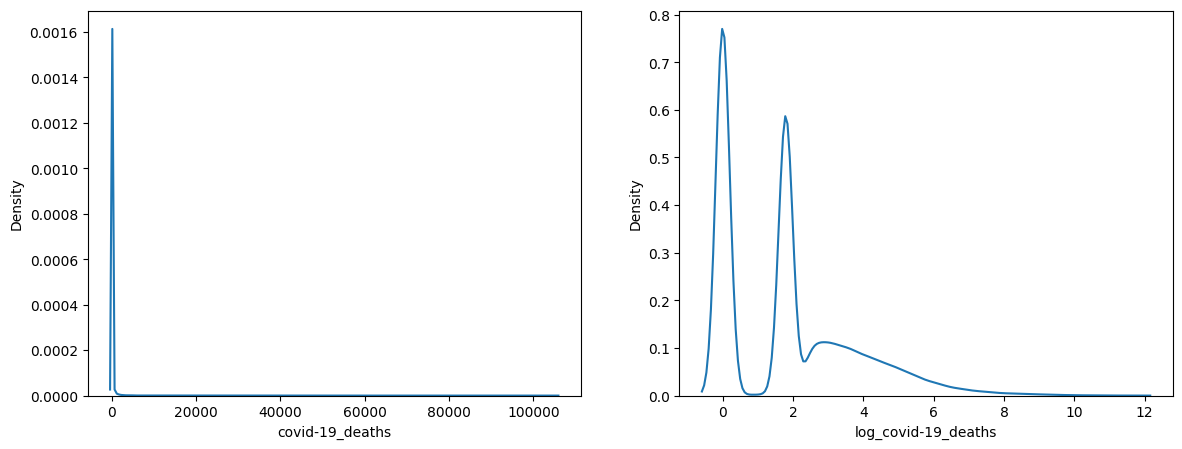





 skewness  before and after in the column covid-19_deaths 40.12063444899349 0.9640984479664657




outliers count for covid-19_deaths:  (12770, 17)
----------------------------------------------------------------------------


total_deaths


count     80258.000000
mean       1138.665217
std        8966.194588
min           0.000000
25%          18.000000
50%          86.000000
75%         393.000000
max      373641.000000
Name: total_deaths, dtype: float64
Skewness in total_deaths 22.00950327267023





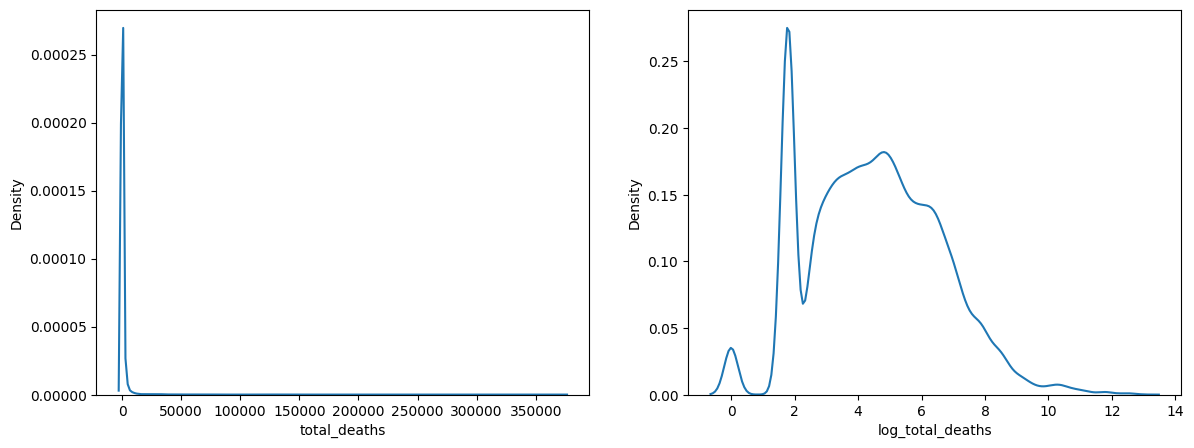





 skewness  before and after in the column total_deaths 22.00950327267023 0.2974143457233869




outliers count for total_deaths:  (10577, 17)
----------------------------------------------------------------------------


pneumonia_deaths


count    80258.000000
mean       107.641157
std        974.927657
min          0.000000
25%          0.000000
50%          5.000000
75%         29.000000
max      69849.000000
Name: pneumonia_deaths, dtype: float64
Skewness in pneumonia_deaths 30.123871836497727





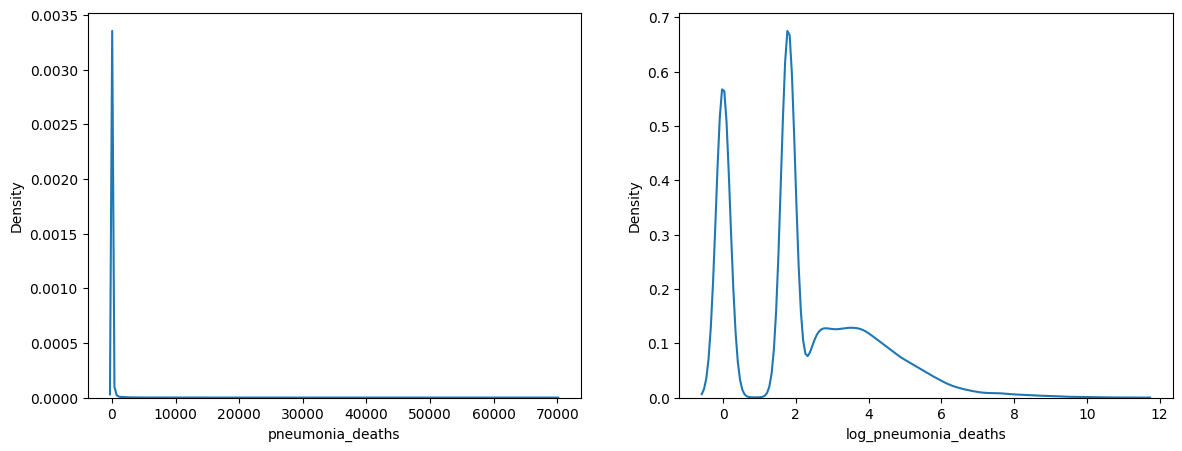





 skewness  before and after in the column pneumonia_deaths 30.123871836497727 0.7298318628092073




outliers count for pneumonia_deaths:  (11393, 17)
----------------------------------------------------------------------------


pneumonia_and_covid-19_deaths


count    80258.000000
mean        53.416918
std        622.826211
min          0.000000
25%          0.000000
50%          5.000000
75%          5.000000
max      55416.000000
Name: pneumonia_and_covid-19_deaths, dtype: float64
Skewness in pneumonia_and_covid-19_deaths 40.43746116753708





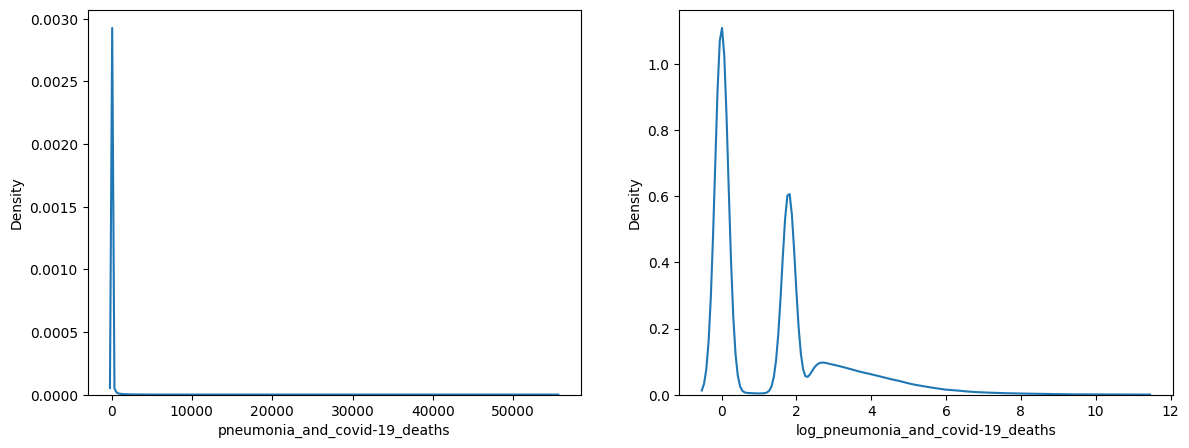





 skewness  before and after in the column pneumonia_and_covid-19_deaths 40.43746116753708 1.2468986025269224




outliers count for pneumonia_and_covid-19_deaths:  (16248, 17)
----------------------------------------------------------------------------


influenza_deaths


count    80258.000000
mean         2.543834
std         33.301975
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4460.000000
Name: influenza_deaths, dtype: float64
Skewness in influenza_deaths 63.76146766498302





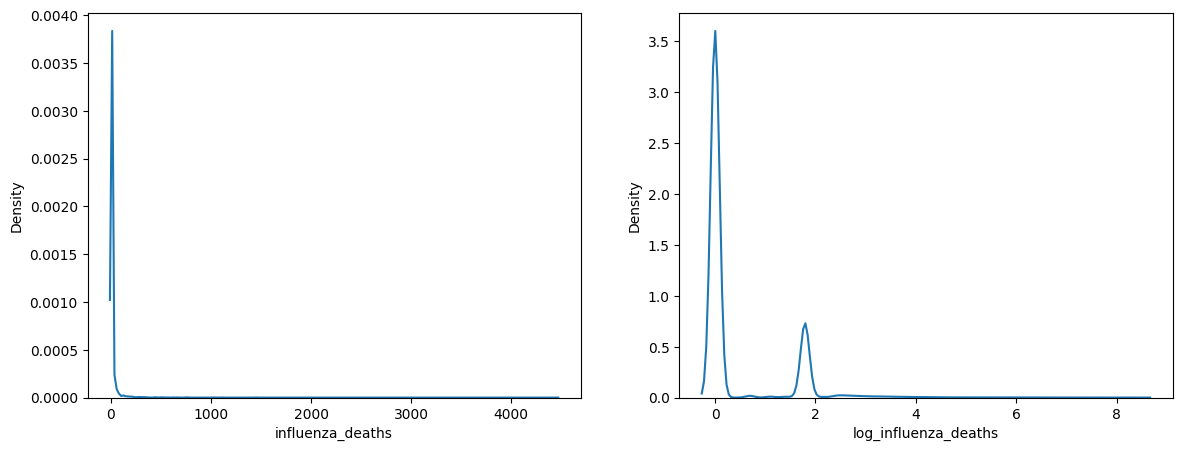





 skewness  before and after in the column influenza_deaths 63.76146766498302 2.268692256852415




outliers count for influenza_deaths:  (16107, 17)
----------------------------------------------------------------------------


pneumonia,_influenza,_or_covid-19_deaths


count     80258.000000
mean        162.073575
std        1551.850158
min           0.000000
25%           5.000000
50%           5.000000
75%          42.000000
max      120079.000000
Name: pneumonia,_influenza,_or_covid-19_deaths, dtype: float64
Skewness in pneumonia,_influenza,_or_covid-19_deaths 33.37148043892712





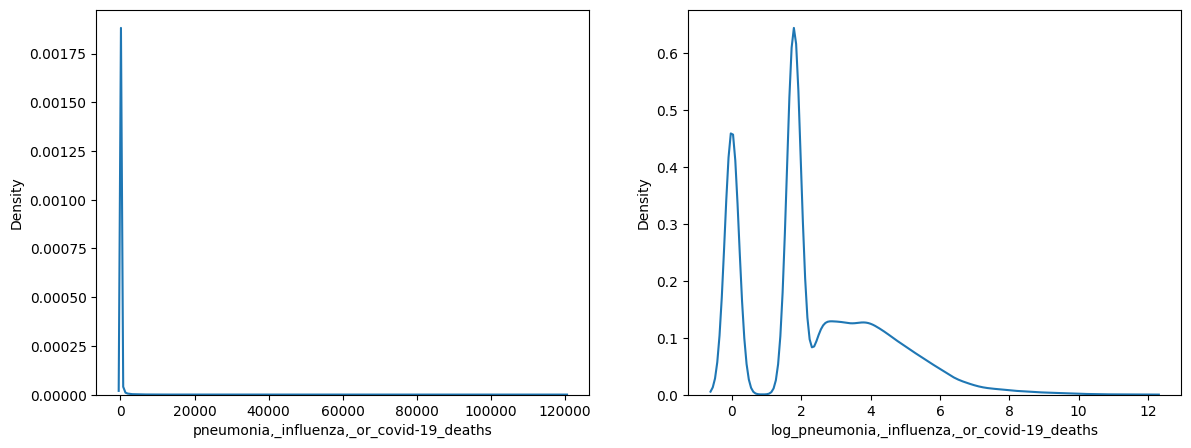





 skewness  before and after in the column pneumonia,_influenza,_or_covid-19_deaths 33.37148043892712 0.680543935933494




outliers count for pneumonia,_influenza,_or_covid-19_deaths:  (12073, 17)
----------------------------------------------------------------------------




In [ ]:
print("Univariate for->")
l=df.select_dtypes(include=np.number)
for i in l:
  print(i,end='\n\n\n')
  univariate_numerical(df, i)
  print('----------------------------------------------------------------------------\n\n')

***# The numerical columns (covid-19_deaths, total_deaths, etc.) are heavily right-skewed due to a high prevalence of zero values  indicating that deaths were absent or low for most of the 2020–2023 period. Peak death events, identified as upper outliers, represent a small fraction of the timespan, underscoring that the majority of this 3-year period experienced significantly lower mortality rates compared to the intense outbreak periods.***

In [ ]:

category

In [ ]:
def univariate_categorical(df, x):
  print(df[x].value_counts(), '\n\n')
  plt.figure(figsize=(10,5))
  sns.countplot(data=df, x=x)
  plt.title(f'Count Plot of {x}')
  if(i=='state' or i=='age_group' or x=='month'):
    plt.xticks(rotation='vertical')

  plt.show()


group


group
By Month    80258
Name: count, dtype: int64 




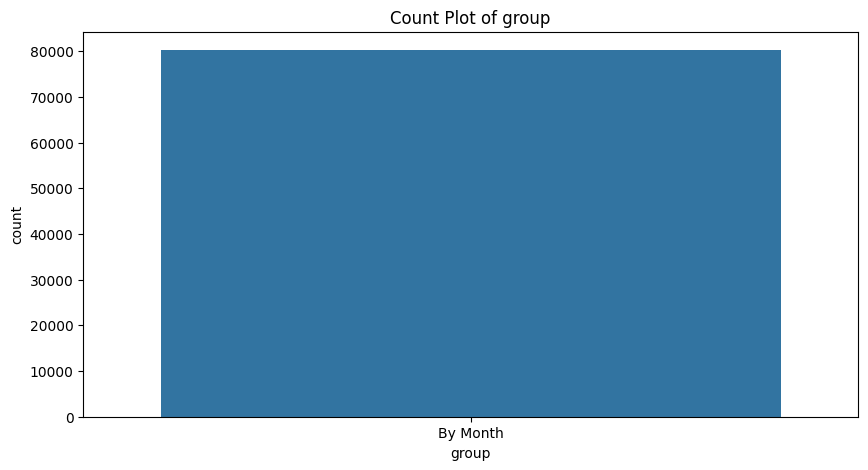




state


state
Alabama                 2295
Alaska                  2295
Arizona                 2295
Arkansas                2295
California              2295
Colorado                2295
Connecticut             2295
Delaware                2295
District of Columbia    2295
Florida                 2295
Georgia                 2295
Hawaii                  2295
Idaho                   2295
Illinois                2295
Indiana                 2295
Iowa                    2295
Kansas                  2295
Kentucky                2295
Louisiana               2295
Maine                   2295
Maryland                2295
Massachusetts           2295
Michigan                2295
Minnesota               2295
Mississippi             2295
Missouri                2295
Montana                 2295
Nebraska                2295
Nevada                  2295
New Hampshire           2295
New Jersey              2295
New Mexico              2295
New York                2295
United States           22

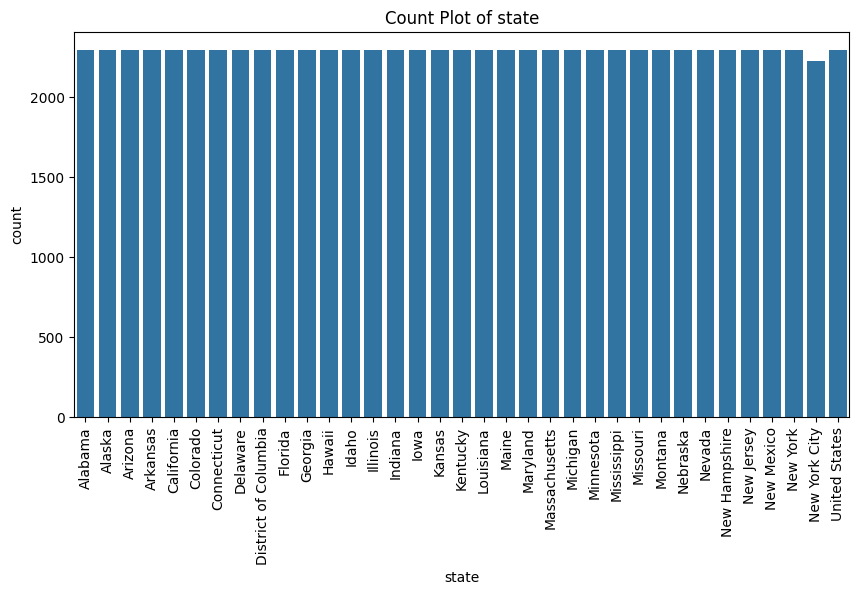




sex


sex
All Sexes    26758
Male         26758
Female       26742
Name: count, dtype: int64 




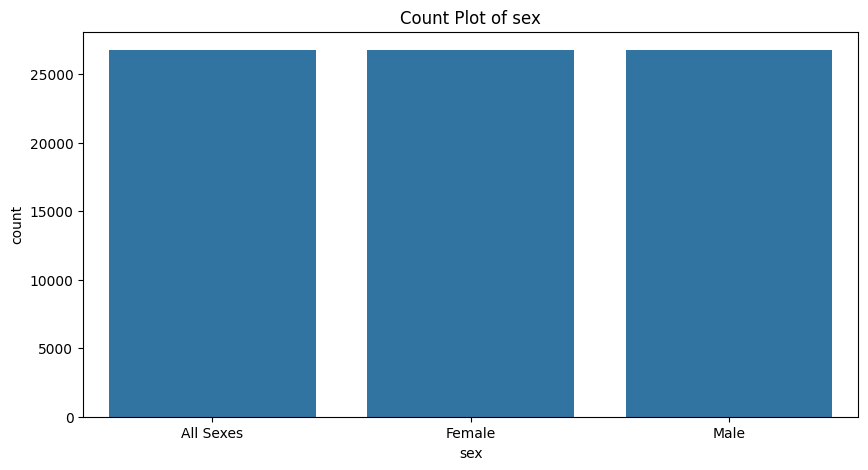




age_group


age_group
All Ages             4722
0-17 years           4721
1-4 years            4721
18-29 years          4721
15-24 years          4721
30-39 years          4721
35-44 years          4721
40-49 years          4721
25-34 years          4721
45-54 years          4721
5-14 years           4721
55-64 years          4721
50-64 years          4721
65-74 years          4721
75-84 years          4721
85 years and over    4721
Under 1 year         4721
Name: count, dtype: int64 




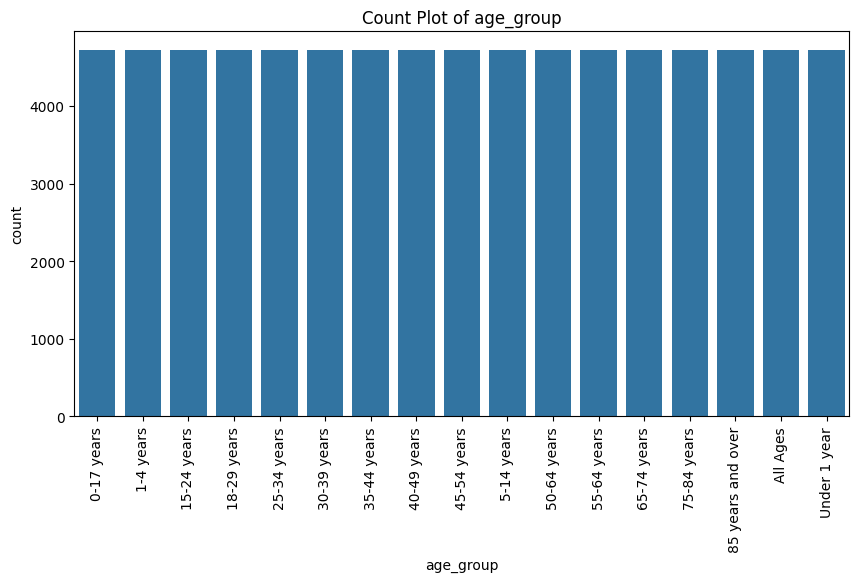




footnote


footnote
One or more data cells have counts between 1-9 and have been suppressed in accordance with NCHS confidentiality standards.    56714
Name: count, dtype: int64 




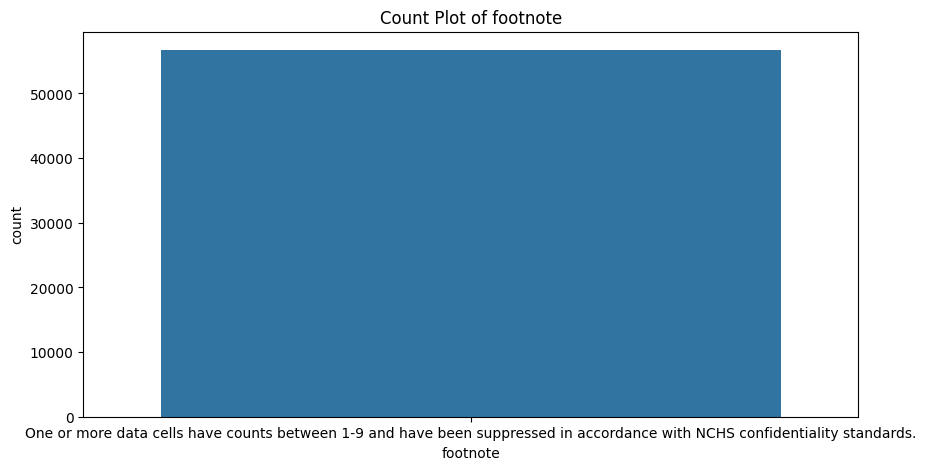




year


year
2020.0    21420
2021.0    21420
2022.0    21420
2023.0    15998
Name: count, dtype: int64 




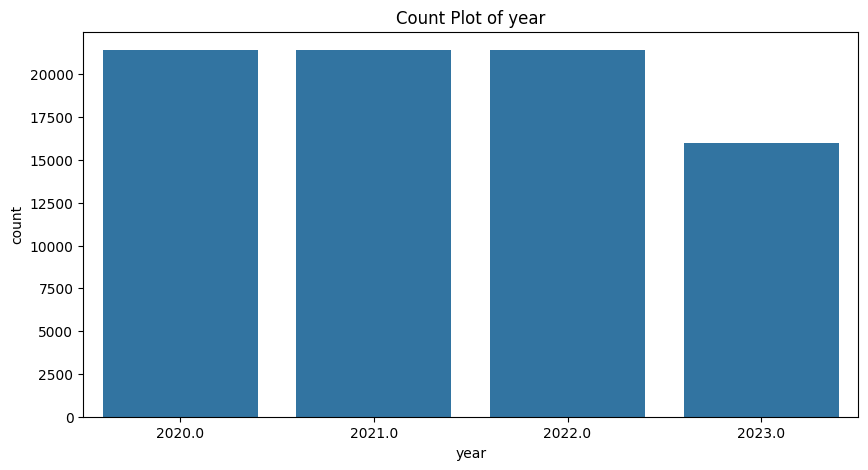




month


month
April        7140
February     7140
July         7140
January      7140
May          7140
March        7140
June         7140
August       7124
September    7089
December     5355
November     5355
October      5355
Name: count, dtype: int64 




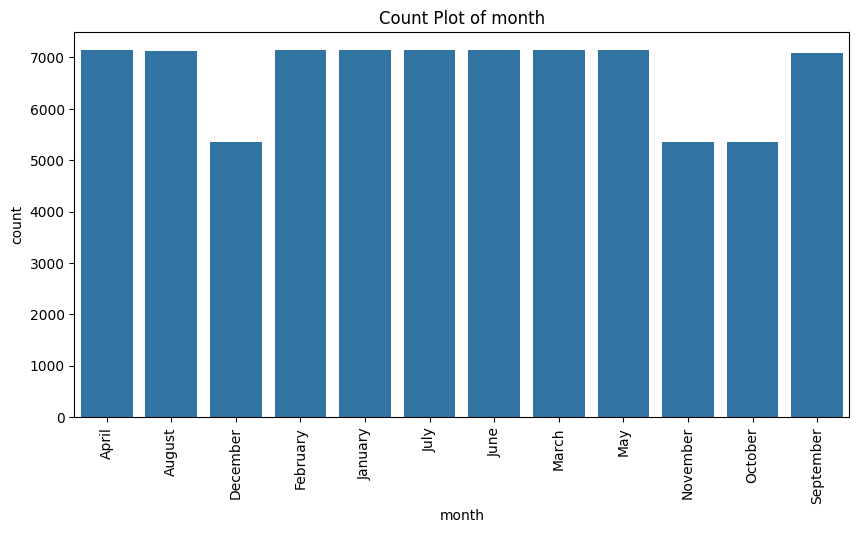

In [ ]:
for i in category:
  print(i,end='\n\n\n')
  univariate_categorical(df, i)
  print('\n\n')
  # print(df[i].value_counts(), '\n\n')

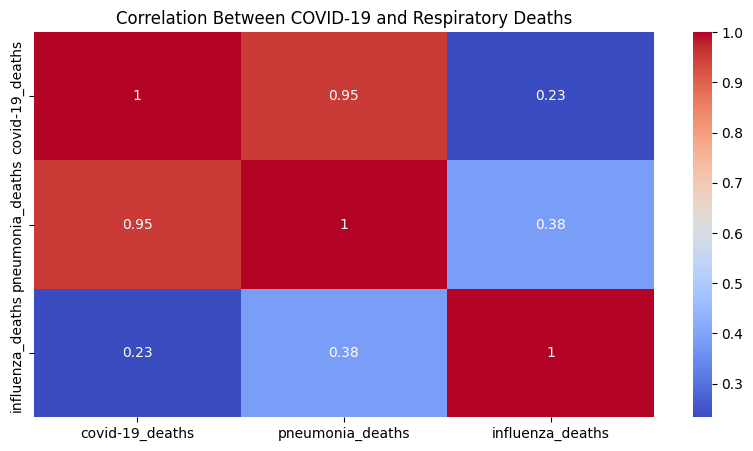

In [ ]:
#multivariate
df_numeric=df[['covid-19_deaths','pneumonia_deaths', 'influenza_deaths']]
corr=df_numeric.corr()
plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between COVID-19 and Respiratory Deaths")
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
sns.pairplot(df[['covid-19_deaths', 'pneumonia_deaths', 'influenza_deaths']])
plt.show()

# **Covid-19 deaths and pneumonia_deaths are highly co-related, they have a correation of 0.98**

data is equally distributted among each category
except for
months of year -> 2023 the data is avalable only till september
on counting months by

1.`COVID-19 Deaths by Age Group & Sex`


In [ ]:
df_agg=df.groupby(['age_group', 'sex'])['covid-19_deaths'].sum()
df_agg=df_agg.reset_index()
df_agg

/tmp/ipython-input-1169263508.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg=df.groupby(['age_group', 'sex'])['covid-19_deaths'].sum()


,age_group,sex,covid-19_deaths
0,0-17 years,All Sexes,4484.0
1,0-17 years,Female,2407.0
2,0-17 years,Male,2703.0
3,1-4 years,All Sexes,1020.0
4,1-4 years,Female,524.0
5,1-4 years,Male,546.0
6,15-24 years,All Sexes,6463.0
7,15-24 years,Female,3096.0
8,15-24 years,Male,4309.0
9,18-29 years,All Sexes,13207.0


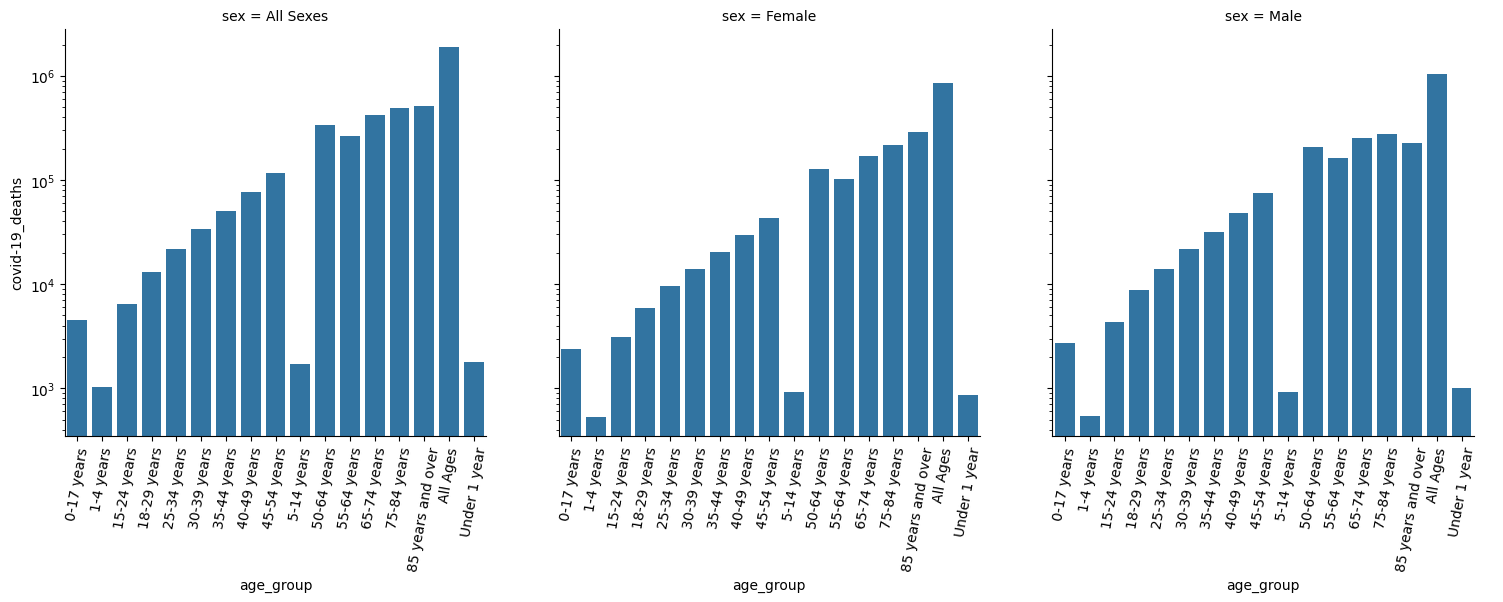

In [ ]:

g=sns.catplot(kind='bar',data=df_agg, col='sex', y='covid-19_deaths', x='age_group')

for ax in g.axes.flat:
    ax.set_yscale('log')

for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=80)

plt.show()




2 `Sex-based Mortality Analysis`

In [ ]:

df_sex = df.groupby('sex')['total_deaths'].sum().reset_index()
df_sex

/tmp/ipython-input-3408706432.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sex = df.groupby('sex')['total_deaths'].sum().reset_index()


,sex,total_deaths
0,All Sexes,45692053.0
1,Female,21080723.0
2,Male,24614217.0


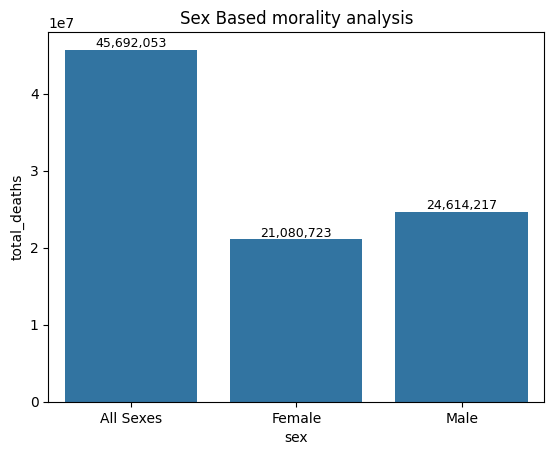

In [ ]:
sns.barplot(data=df_sex, x='sex', y='total_deaths')
for i, row in df_sex.iterrows():
    plt.text(
        x=i,
        y=row['total_deaths'],
        s=f"{int(row['total_deaths']):,}",  # Correct comma format
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.title('Sex Based morality analysis')

plt.show()

3. `Comparison of COVID-19, Pneumonia, and Influenza Death`

/tmp/ipython-input-1602551098.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg2=df.groupby('year')


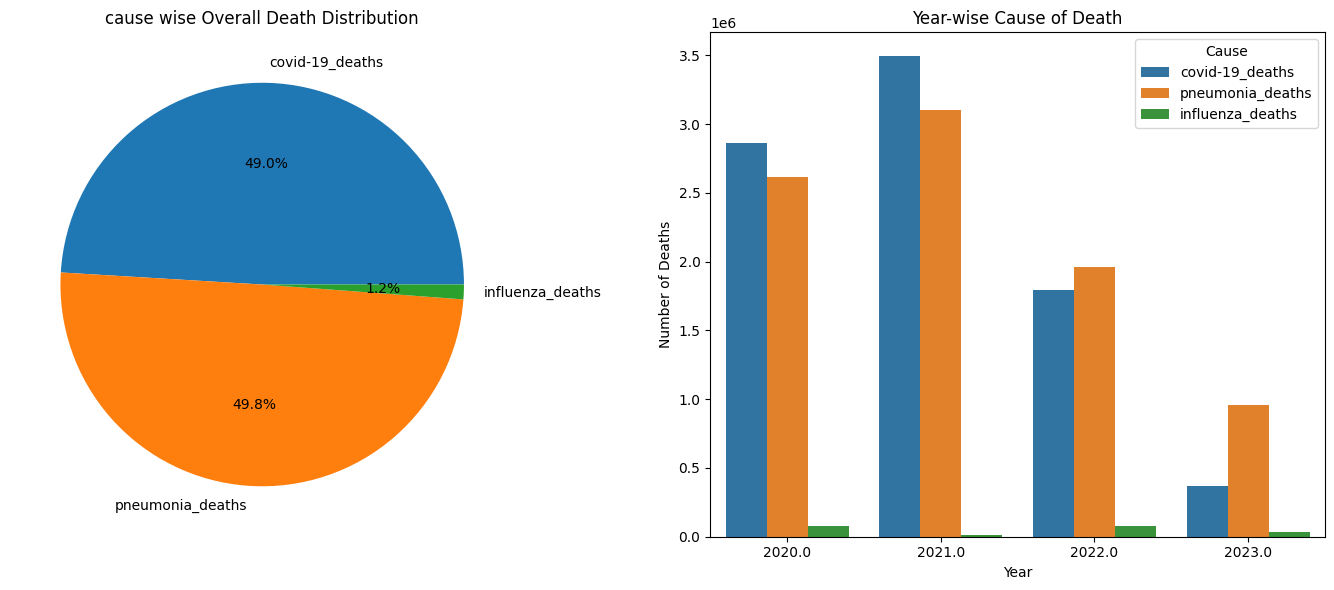

In [ ]:
df_agg=df[['covid-19_deaths','pneumonia_deaths','influenza_deaths']].sum()
# print(df_agg)


df_agg2=df.groupby('year')
df_agg2=df_agg2[['covid-19_deaths','pneumonia_deaths','influenza_deaths']].sum()
df_agg2.reset_index(inplace=True)
# print(df_agg2)
df_melted = df_agg2.melt(id_vars='year',
                         value_vars=['covid-19_deaths', 'pneumonia_deaths', 'influenza_deaths'],
                         var_name='Cause',
                         value_name='Deaths')
# print(df_melted)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#comparing for over all  3 years
axes[0].pie(df_agg.values, labels=df_agg.index, autopct='%1.1f%%')
axes[0].set_title('cause wise Overall Death Distribution')

#year wise comparision
sns.barplot(data=df_melted, x='year', y='Deaths', hue='Cause', ax=axes[1])
axes[1].set_title('Year-wise Cause of Death')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Deaths')

plt.tight_layout()
plt.show()

4.`Identify the Month with Peak COVID-19 Mortality for Each State`

In [ ]:
df_ym=df[['year','month','state','covid-19_deaths']]
df_ym=df_ym.groupby(['state','year','month'])

/tmp/ipython-input-3216848084.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ym=df_ym.groupby(['state','year','month'])


In [ ]:
df_ym=df_ym['covid-19_deaths'].sum().reset_index()
df_ym

,state,year,month,covid-19_deaths
0,Alabama,2020.0,April,1536.0
1,Alabama,2020.0,August,4323.0
2,Alabama,2020.0,December,7690.0
3,Alabama,2020.0,February,20.0
4,Alabama,2020.0,January,30.0
...,...,...,...,...
1675,United States,2023.0,March,32174.0
1676,United States,2023.0,May,14978.0
1677,United States,2023.0,November,0.0
1678,United States,2023.0,October,0.0


In [ ]:
df_ym=df_ym.sort_values(by='covid-19_deaths',ascending=False)
df_ym=df_ym.drop_duplicates('state')
df_ym['month-year']=df_ym['month'].astype('str') + ' - ' + df_ym['year'].astype('str')
df_ym

,state,year,month,covid-19_deaths,month-year
1648,United States,2021.0,January,462640.0,January - 2021.0
208,California,2021.0,January,90937.0,January - 2021.0
1584,New York City,2020.0,April,67220.0,April - 2020.0
445,Florida,2021.0,August,49855.0,August - 2021.0
1440,New Jersey,2020.0,April,39732.0,April - 2020.0
1536,New York,2020.0,April,31908.0,April - 2020.0
503,Georgia,2021.0,September,18756.0,September - 2021.0
112,Arizona,2021.0,January,18068.0,January - 2021.0
626,Illinois,2020.0,December,17991.0,December - 2020.0
1008,Massachusetts,2020.0,April,16485.0,April - 2020.0


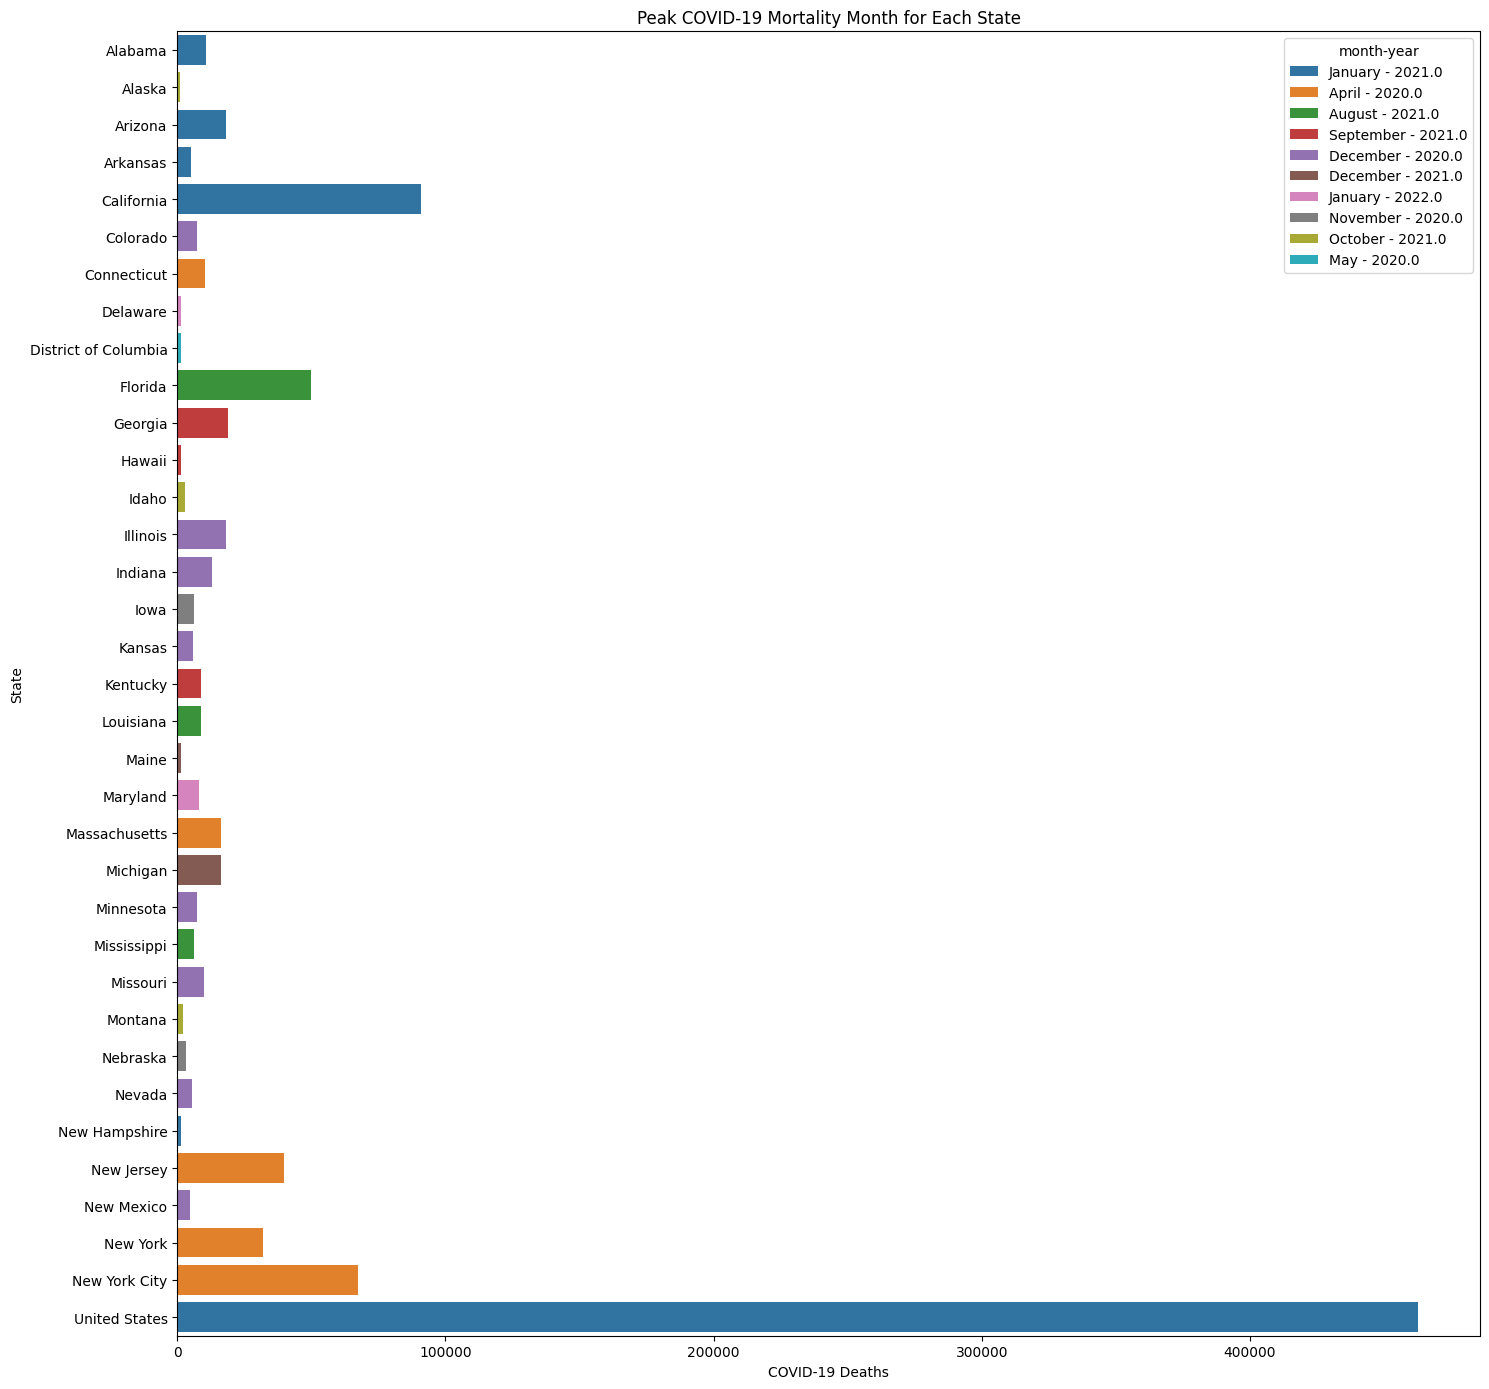

In [ ]:
df_ym
plt.figure(figsize=(15, 14))
sns.barplot(data=df_ym, y='state', x='covid-19_deaths',hue='month-year')

plt.title('Peak COVID-19 Mortality Month for Each State')
plt.xlabel('COVID-19 Deaths')
plt.ylabel('State')
plt.tight_layout()
plt.show()

5. `COVID Deaths as % of Total Deaths`

In [ ]:
val=( df['covid-19_deaths'].sum() / df['total_deaths'].sum() )*100
print("COVID Deaths as % of Total Deaths",val, '%')

COVID Deaths as % of Total Deaths 9.31478618625738 %


-> `year wise covid deaths percentage of total deaths`

In [ ]:
df_year=df.groupby('year')

/tmp/ipython-input-1096234374.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_year=df.groupby('year')


In [ ]:
df_year_sum=df_year[['covid-19_deaths','total_deaths']].sum()

In [ ]:
df_year_sum['covid%']=df_year_sum['covid-19_deaths']/df_year_sum['total_deaths']*100

In [ ]:
df_year_sum

,covid-19_deaths,total_deaths,covid%
year,,,
2020.0,2859376.0,25221985.0,11.336840
2021.0,3492912.0,25927365.0,13.471913
2022.0,1791027.0,24369033.0,7.349602
2023.0,369188.0,15868610.0,2.326530


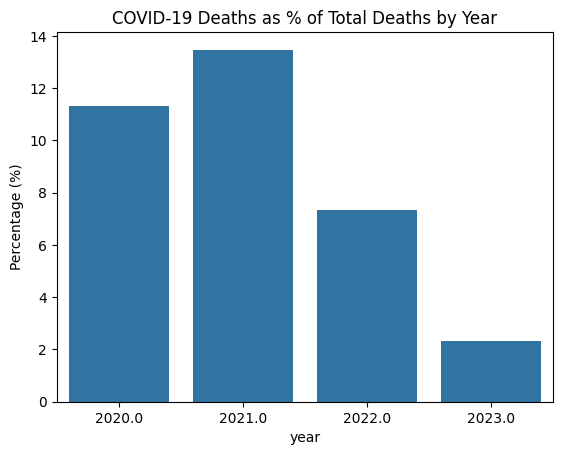

In [ ]:
sns.barplot(data=df_year_sum, x='year', y='covid%')
plt.title('COVID-19 Deaths as % of Total Deaths by Year')
plt.ylabel('Percentage (%)')
plt.xlabel('year')
plt.show()

6. `Monthly COVID-19 Death Trends`

In [ ]:
#6
df_ym=df.groupby(['year','month'])

/tmp/ipython-input-388368864.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ym=df.groupby(['year','month'])


In [ ]:
df_ym=df_ym['covid-19_deaths'].sum().reset_index()

In [ ]:
df_ym

,year,month,covid-19_deaths
0,2020.0,April,538045.0
1,2020.0,August,218721.0
2,2020.0,December,696086.0
3,2020.0,February,432.0
4,2020.0,January,118.0
5,2020.0,July,227351.0
6,2020.0,June,139645.0
7,2020.0,March,62102.0
8,2020.0,May,300028.0
9,2020.0,November,367358.0


In [ ]:
# Create custom labels like "Apr 2020"
df_ym['month_year'] = df_ym['month'].str[:3] + ' ' + df_ym['year'].astype(str)
df_ym

,year,month,covid-19_deaths,month_year
0,2020.0,April,538045.0,Apr 2020.0
1,2020.0,August,218721.0,Aug 2020.0
2,2020.0,December,696086.0,Dec 2020.0
3,2020.0,February,432.0,Feb 2020.0
4,2020.0,January,118.0,Jan 2020.0
5,2020.0,July,227351.0,Jul 2020.0
6,2020.0,June,139645.0,Jun 2020.0
7,2020.0,March,62102.0,Mar 2020.0
8,2020.0,May,300028.0,May 2020.0
9,2020.0,November,367358.0,Nov 2020.0


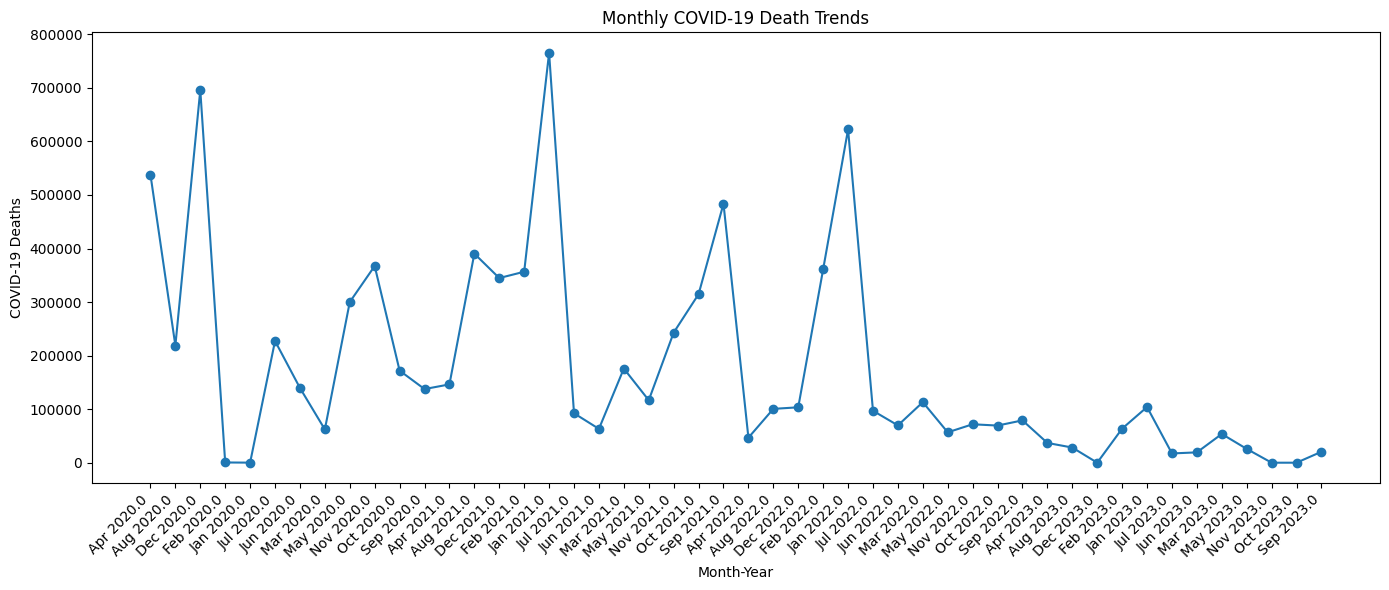

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df_ym['month_year'], df_ym['covid-19_deaths'], marker='o')

plt.xticks(rotation=45, ha='right')
plt.title('Monthly COVID-19 Death Trends')
plt.xlabel('Month-Year')
plt.ylabel('COVID-19 Deaths')
plt.tight_layout()
plt.show()
